In [79]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import (
    HuberRegressor,
    LinearRegression,
    LogisticRegression,
    QuantileRegressor,
    Ridge,
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    PolynomialFeatures,
    SplineTransformer,
    StandardScaler,
)
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer

RANDOM_STATE = 280926

In [80]:
train = pd.read_csv("QSAR_challenge_train_80pct.csv")
test = pd.read_csv("QSAR_challenge_test_20pct_NO_TARGETS.csv")

In [81]:
train.shape

(623, 12)

In [82]:
train

,sample_id,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O],regression_target,classification_target
0,2234-13-1,8.0,7.157,2.41,0.21,6.55,0.97,0.0,0.0,0.0,2.58,3
1,108-42-9,1.0,0.000,1.23,0.20,2.13,0.68,0.0,1.0,NaN,0.33,3
2,106-43-4,1.0,0.000,1.23,0.22,3.21,0.84,0.0,0.0,0.0,1.80,1
3,108-87-2,0.0,0.000,0.00,0.34,3.48,1.67,0.0,0.0,0.0,2.32,1
4,101-81-5,0.0,5.614,2.21,0.19,4.15,1.47,0.0,0.0,0.0,2.97,1
...,...,...,...,...,...,...,...,...,...,...,...,...
618,17700-09-3,3.0,0.000,1.49,0.18,3.70,0.69,0.0,1.0,4.0,2.20,1
619,5915-41-3,1.0,3.056,1.21,0.21,2.89,1.90,0.0,1.0,0.0,0.84,3
620,39515-41-8/64257-84-7,0.0,6.428,2.25,0.19,3.56,2.92,0.0,1.0,15.0,3.04,3
621,26644-46-2,6.0,4.043,0.16,0.29,1.40,1.86,2.0,1.0,2.0,0.00,3


In [83]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sample_id              623 non-null    str    
 1   nHM                    612 non-null    float64
 2   piPC09                 610 non-null    float64
 3   PCD                    616 non-null    float64
 4   X2Av                   611 non-null    float64
 5   MLOGP                  610 non-null    float64
 6   ON1V                   609 non-null    float64
 7   N-072                  604 non-null    float64
 8   B02[C-N]               616 non-null    float64
 9   F04[C-O]               607 non-null    float64
 10  regression_target      623 non-null    float64
 11  classification_target  623 non-null    int64  
dtypes: float64(10), int64(1), str(1)
memory usage: 58.5 KB


In [84]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  156 non-null    str    
 1   nHM        153 non-null    float64
 2   piPC09     152 non-null    float64
 3   PCD        151 non-null    float64
 4   X2Av       153 non-null    float64
 5   MLOGP      154 non-null    float64
 6   ON1V       154 non-null    float64
 7   N-072      153 non-null    float64
 8   B02[C-N]   153 non-null    float64
 9   F04[C-O]   153 non-null    float64
dtypes: float64(9), str(1)
memory usage: 12.3 KB


In [85]:
def visualize_col_distr(df, n_cols=3, n_rows=4):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
    axes = axes.flatten()

    for i, col in enumerate(df.columns):
        if col == "sample_id":
            continue
        axes[i].hist(df[col], bins=20, edgecolor="black")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")
        axes[i].set_title(f"{col} distribution")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

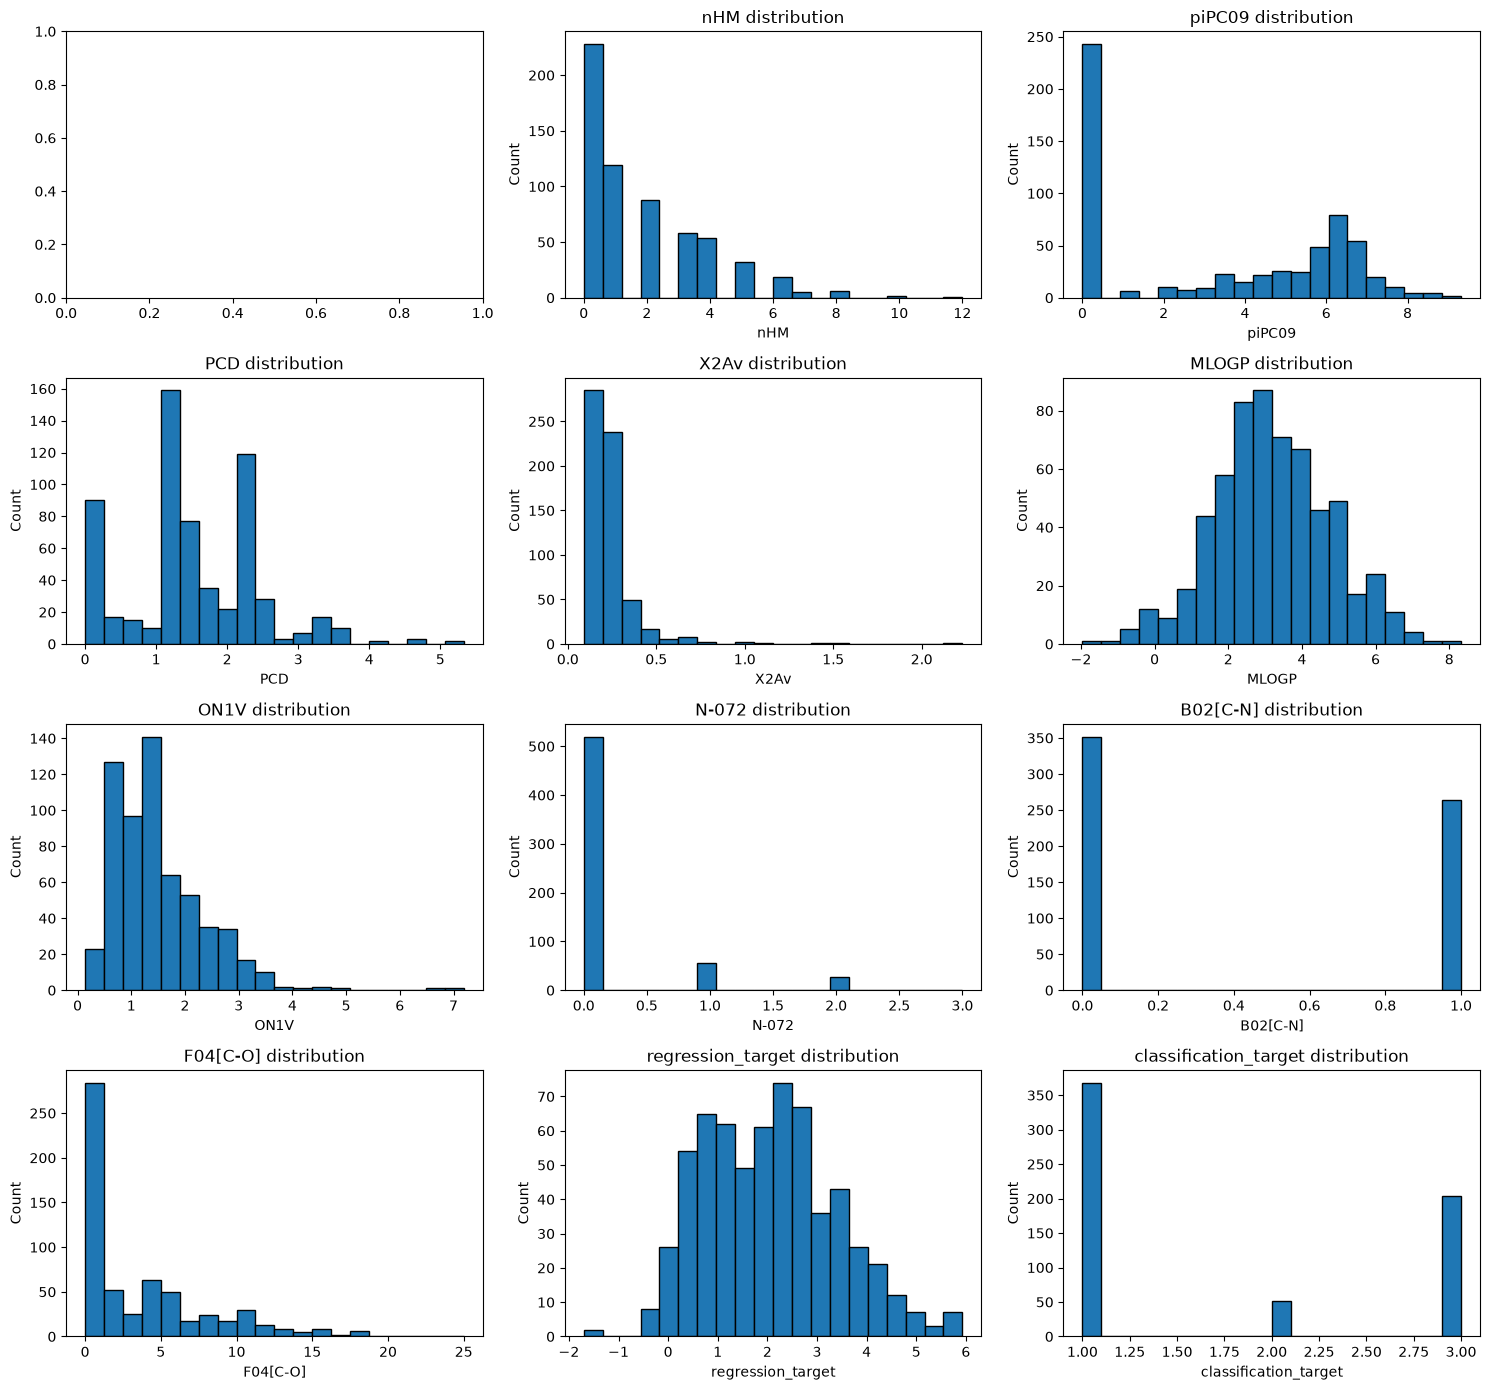

In [86]:
visualize_col_distr(train)

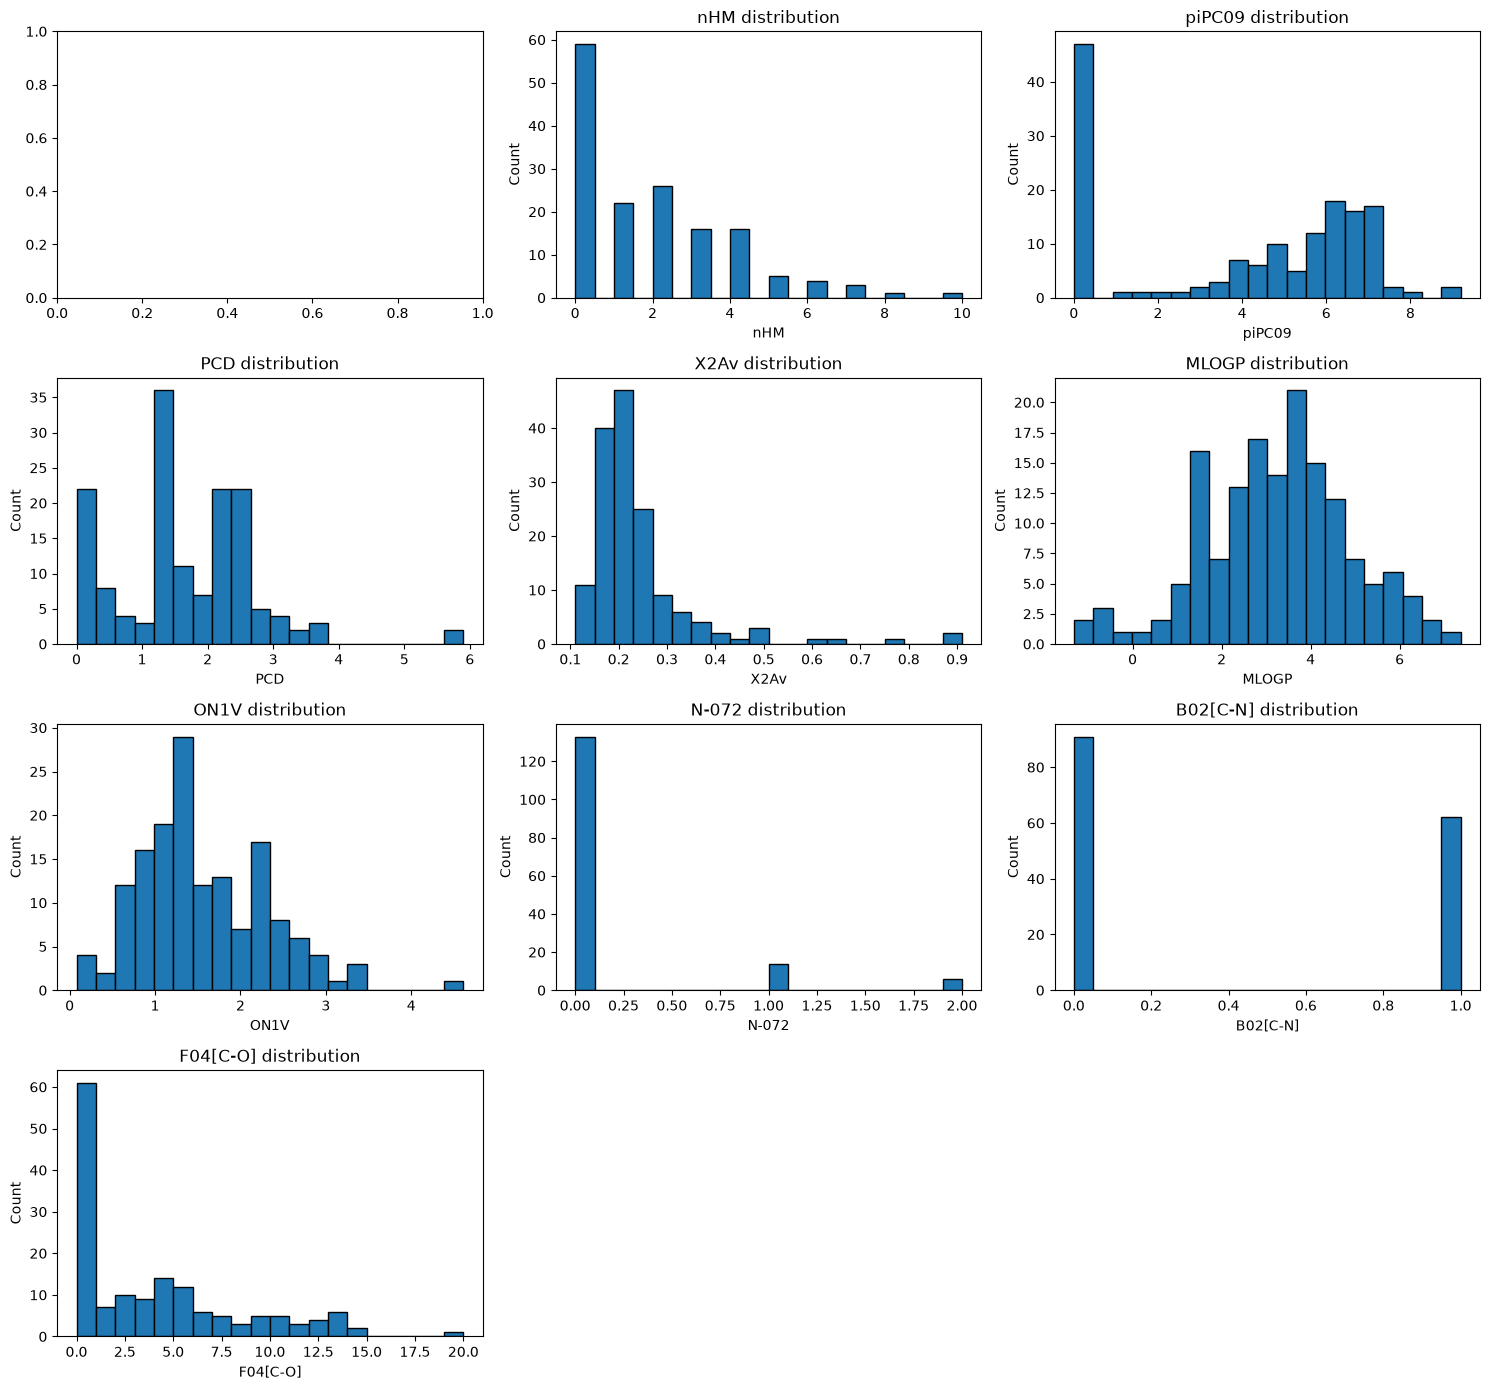

In [87]:
visualize_col_distr(test)

In [ ]:
train = train[train["nHM"] <= 10]
train = train[train["ON1V"] <= 5]
train = train[train["X2Av"] <= 1]
train = train[train["N-072"] <= 2]
train = train[train["F04[C-O]"] <= 20]
train.reset_index(drop=True, inplace=True)

In [89]:
train.describe()

,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O],regression_target,classification_target
count,543.000000,531.000000,538.000000,543.000000,533.000000,543.000000,543.000000,536.000000,543.000000,543.000000,543.00000
mean,1.771639,3.330217,1.554442,0.227587,3.173752,1.467772,0.193370,0.430970,3.484346,2.031768,1.74954
std,1.958840,2.992919,0.927043,0.104965,1.576834,0.783011,0.505863,0.495675,4.318419,1.329437,0.92718
min,0.000000,0.000000,0.000000,0.090000,-1.430000,0.140000,0.000000,0.000000,0.000000,-1.700000,1.00000
25%,0.000000,0.000000,1.220000,0.170000,2.190000,0.845000,0.000000,0.000000,0.000000,0.970000,1.00000
50%,1.000000,3.992000,1.400000,0.200000,3.130000,1.250000,0.000000,0.000000,2.000000,1.990000,1.00000
75%,3.000000,6.194500,2.280000,0.240000,4.190000,1.870000,0.000000,1.000000,6.000000,2.835000,3.00000
max,10.000000,9.298000,5.290000,0.980000,8.320000,4.630000,2.000000,1.000000,19.000000,5.930000,3.00000


In [90]:
test.describe()

,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O]
count,153.000000,152.000000,151.000000,153.000000,154.000000,154.000000,153.000000,153.000000,153.000000
mean,1.790850,3.964388,1.639404,0.237386,3.267338,1.557338,0.169935,0.405229,3.705882
std,2.011983,2.928426,1.059657,0.121356,1.650596,0.763523,0.470034,0.492549,4.332986
min,0.000000,0.000000,0.000000,0.110000,-1.320000,0.080000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.190000,0.170000,2.220000,1.045000,0.000000,0.000000,0.000000
50%,1.000000,5.023000,1.500000,0.210000,3.340000,1.365000,0.000000,0.000000,2.000000
75%,3.000000,6.427750,2.370000,0.250000,4.272500,2.130000,0.000000,1.000000,6.000000
max,10.000000,9.194000,5.900000,0.910000,7.370000,4.610000,2.000000,1.000000,20.000000


Possibly, removing outliers or adressing the mshould help (for columns F04[C-O], N-072, ON1V, X2Av)

In [91]:
def visualize_relationship(
    df,
    target_column="regression_target",
    exclude=["sample_id", "regression_target", "classification_target"],
    n_rows=3,
    n_cols=3,
):
    features = [feature for feature in df.columns if feature not in exclude]
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 10))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        ax = axes[i]
        ax.scatter(df[feature], df[target_column], alpha=0.7, color="tab:blue")

        ax.set_xlabel(f"{feature}")
        ax.set_ylabel(target_column)
        ax.set_title(f"{feature} vs Regression target")
    plt.tight_layout()
    plt.show()

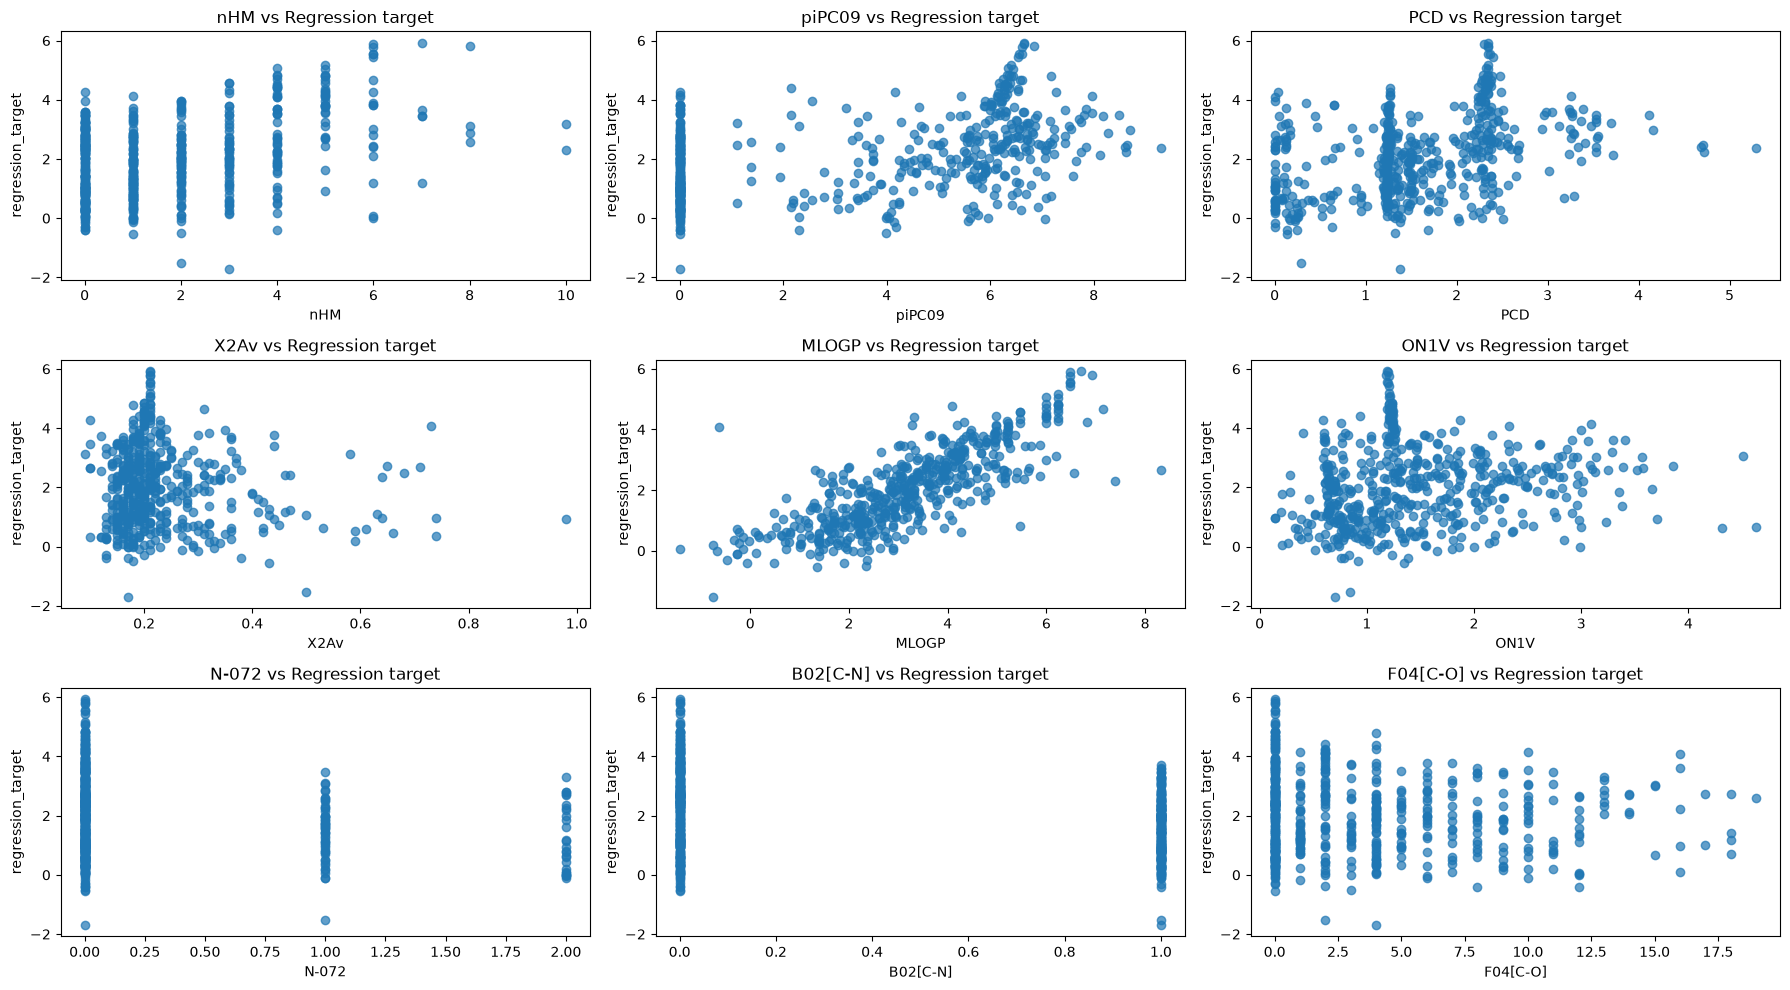

In [92]:
visualize_relationship(train)

In [93]:
train.isna().sum()

sample_id                 0
nHM                       0
piPC09                   12
PCD                       5
X2Av                      0
MLOGP                    10
ON1V                      0
N-072                     0
B02[C-N]                  7
F04[C-O]                  0
regression_target         0
classification_target     0
dtype: int64

In [94]:
train[train.isnull().any(axis=1)]

,sample_id,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O],regression_target,classification_target
6,25311-71-1,2.0,NaN,1.39,0.28,2.99,2.96,0.0,1.0,14.0,2.12,3
90,779-02-2,0.0,NaN,3.54,0.16,4.59,1.67,0.0,0.0,0.0,2.72,3
94,834-12-8,1.0,3.446,NaN,0.21,2.59,2.01,0.0,1.0,0.0,1.52,1
100,57117-39-2,4.0,NaN,3.26,0.18,4.97,1.21,0.0,0.0,2.0,2.72,3
111,108-39-4,0.0,0.000,1.23,0.18,NaN,0.86,0.0,0.0,2.0,1.03,1
120,39807-15-3,2.0,6.332,NaN,0.19,3.95,1.99,1.0,1.0,6.0,2.82,1
191,60207-90-1,2.0,NaN,1.51,0.18,4.17,2.48,0.0,1.0,8.0,2.06,1
192,98-15-7,1.0,0.000,1.20,0.15,3.95,0.76,0.0,NaN,0.0,2.34,2
203,81777-89-1,1.0,5.053,1.24,0.20,2.68,1.72,1.0,NaN,3.0,1.60,1
211,82-45-1,0.0,7.063,2.67,0.14,NaN,1.49,0.0,1.0,10.0,2.03,1


Too many rows and columns with at least one missing value, need to impute

In [95]:
mice_im = IterativeImputer(random_state=RANDOM_STATE)
imputation_train = train.drop(
    columns=["sample_id", "regression_target", "classification_target"],
)
imputed_train = mice_im.fit_transform(imputation_train)
imputation_train = pd.DataFrame(imputed_train, columns=imputation_train.columns)
imputation_train["regression_target"] = train["regression_target"]
imputation_train["classification_target"] = train["classification_target"]

In [96]:
imputation_train

,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O],regression_target,classification_target
0,8.0,7.157,2.41,0.21,6.55,0.97,0.0,0.0,0.0,2.58,3
1,1.0,0.000,1.23,0.22,3.21,0.84,0.0,0.0,0.0,1.80,1
2,0.0,0.000,0.00,0.34,3.48,1.67,0.0,0.0,0.0,2.32,1
3,0.0,5.614,2.21,0.19,4.15,1.47,0.0,0.0,0.0,2.97,1
4,4.0,0.000,1.25,0.36,5.21,0.60,0.0,0.0,0.0,3.70,1
...,...,...,...,...,...,...,...,...,...,...,...
538,3.0,0.000,1.49,0.18,3.70,0.69,0.0,1.0,4.0,2.20,1
539,1.0,3.056,1.21,0.21,2.89,1.90,0.0,1.0,0.0,0.84,3
540,0.0,6.428,2.25,0.19,3.56,2.92,0.0,1.0,15.0,3.04,3
541,6.0,4.043,0.16,0.29,1.40,1.86,2.0,1.0,2.0,0.00,3


In [97]:
imputation_train.isna().sum()

nHM                      0
piPC09                   0
PCD                      0
X2Av                     0
MLOGP                    0
ON1V                     0
N-072                    0
B02[C-N]                 0
F04[C-O]                 0
regression_target        0
classification_target    0
dtype: int64

In [98]:
imputation_train.describe()

,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O],regression_target,classification_target
count,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.00000
mean,1.771639,3.342380,1.555513,0.227587,3.173283,1.467772,0.193370,0.431751,3.484346,2.031768,1.74954
std,1.958840,3.006016,0.924680,0.104965,1.574845,0.783011,0.505863,0.492881,4.318419,1.329437,0.92718
min,0.000000,-1.618146,0.000000,0.090000,-1.430000,0.140000,0.000000,0.000000,0.000000,-1.700000,1.00000
25%,0.000000,0.000000,1.220000,0.170000,2.190000,0.845000,0.000000,0.000000,0.000000,0.970000,1.00000
50%,1.000000,4.007000,1.400000,0.200000,3.120000,1.250000,0.000000,0.000000,2.000000,1.990000,1.00000
75%,3.000000,6.198500,2.280000,0.240000,4.180000,1.870000,0.000000,1.000000,6.000000,2.835000,3.00000
max,10.000000,9.298000,5.290000,0.980000,8.320000,4.630000,2.000000,1.000000,19.000000,5.930000,3.00000


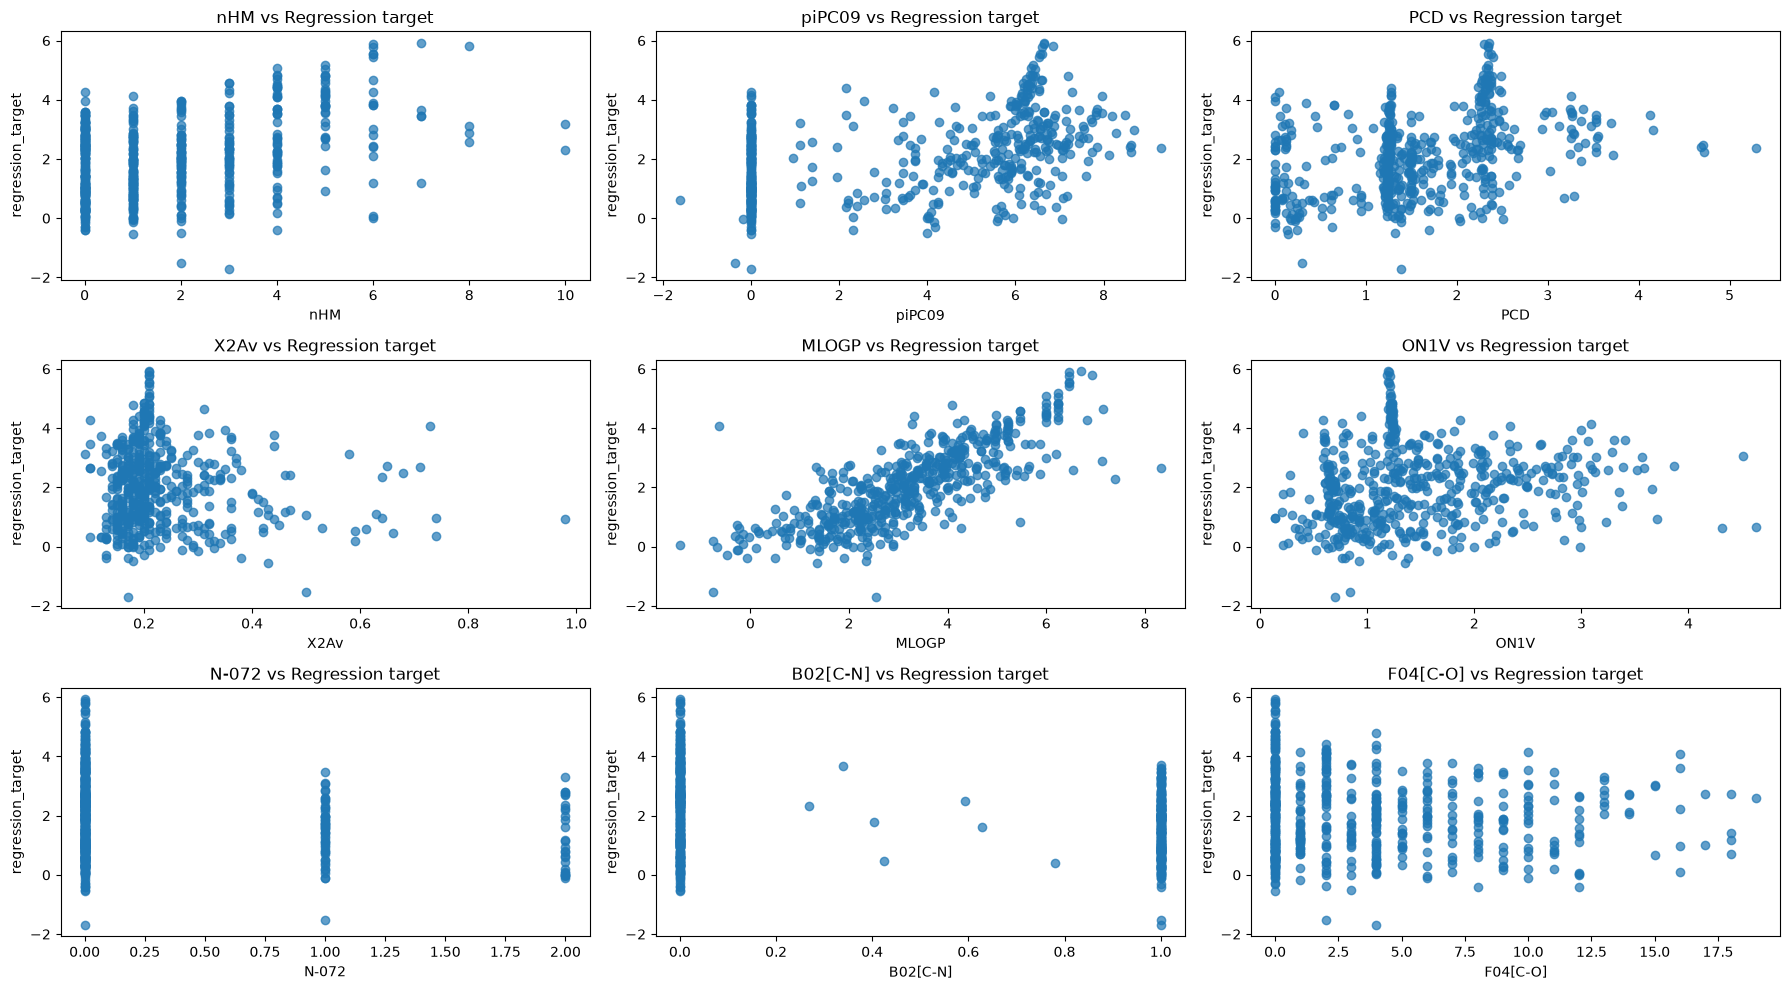

In [99]:
visualize_relationship(imputation_train)

In [100]:
imputation_train["nHM"] = imputation_train["nHM"].round()
imputation_train["N-072"] = imputation_train["N-072"].round()
imputation_train["B02[C-N]"] = imputation_train["B02[C-N]"].round()
imputation_train["F04[C-O]"] = imputation_train["F04[C-O]"].round()

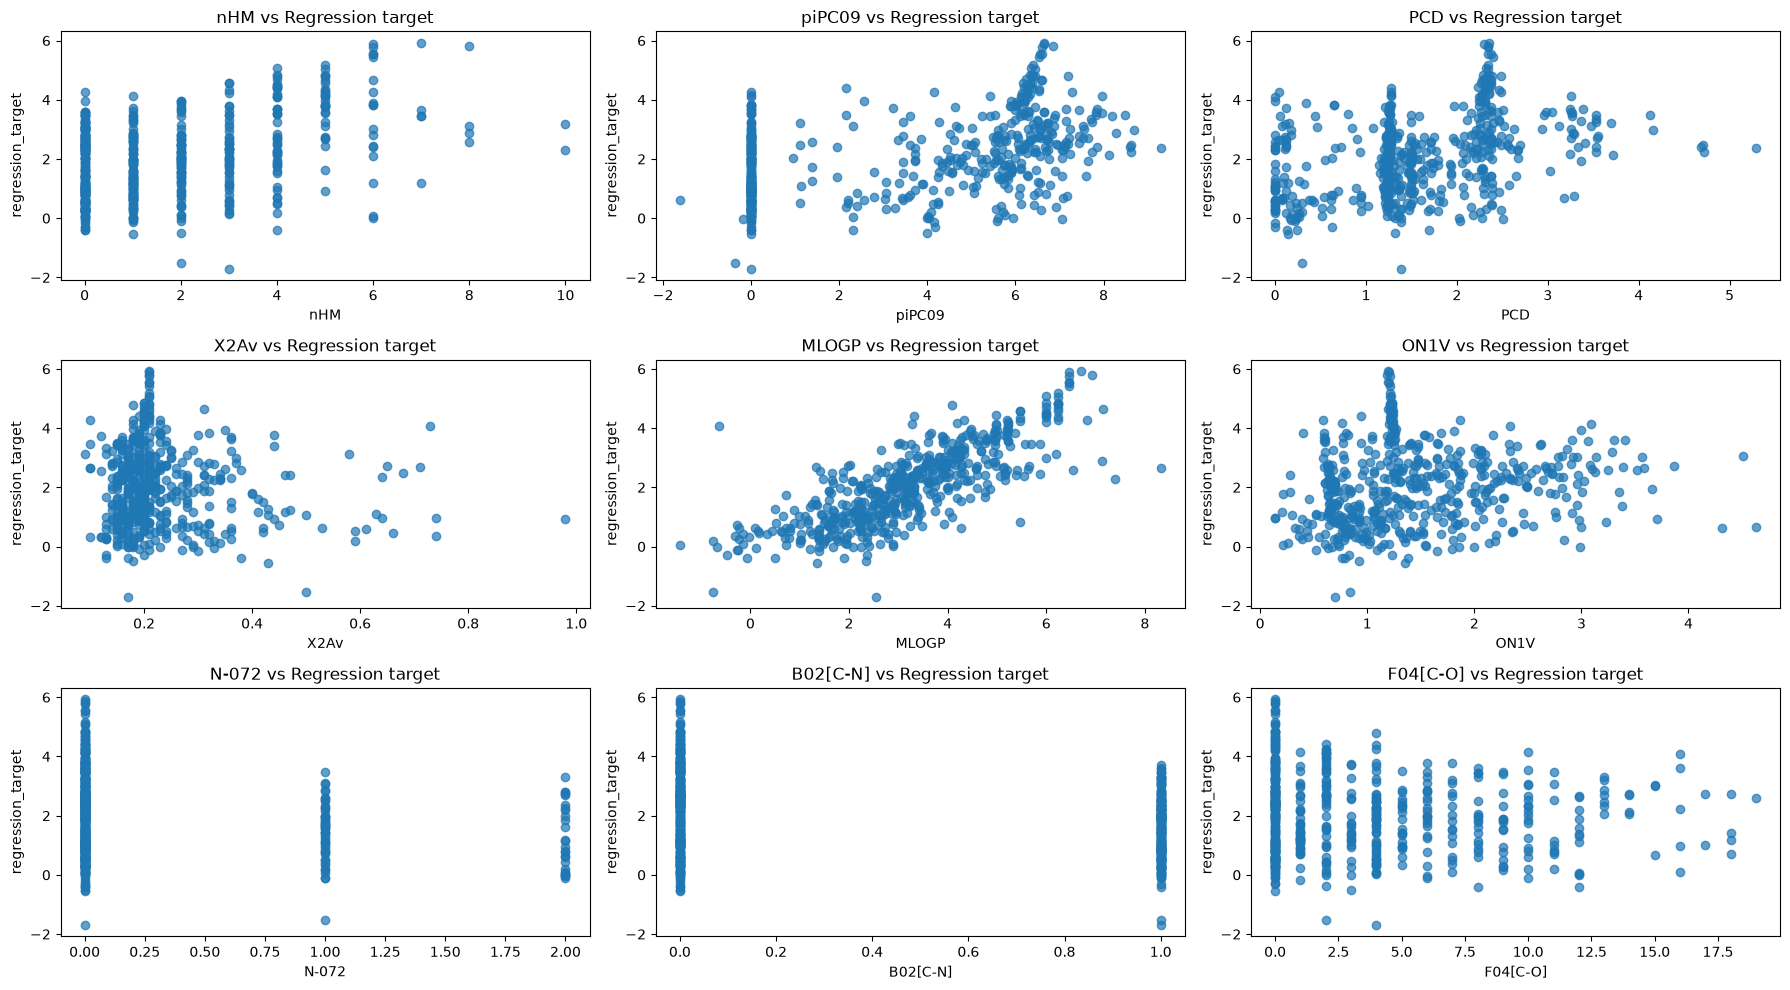

In [101]:
visualize_relationship(imputation_train)

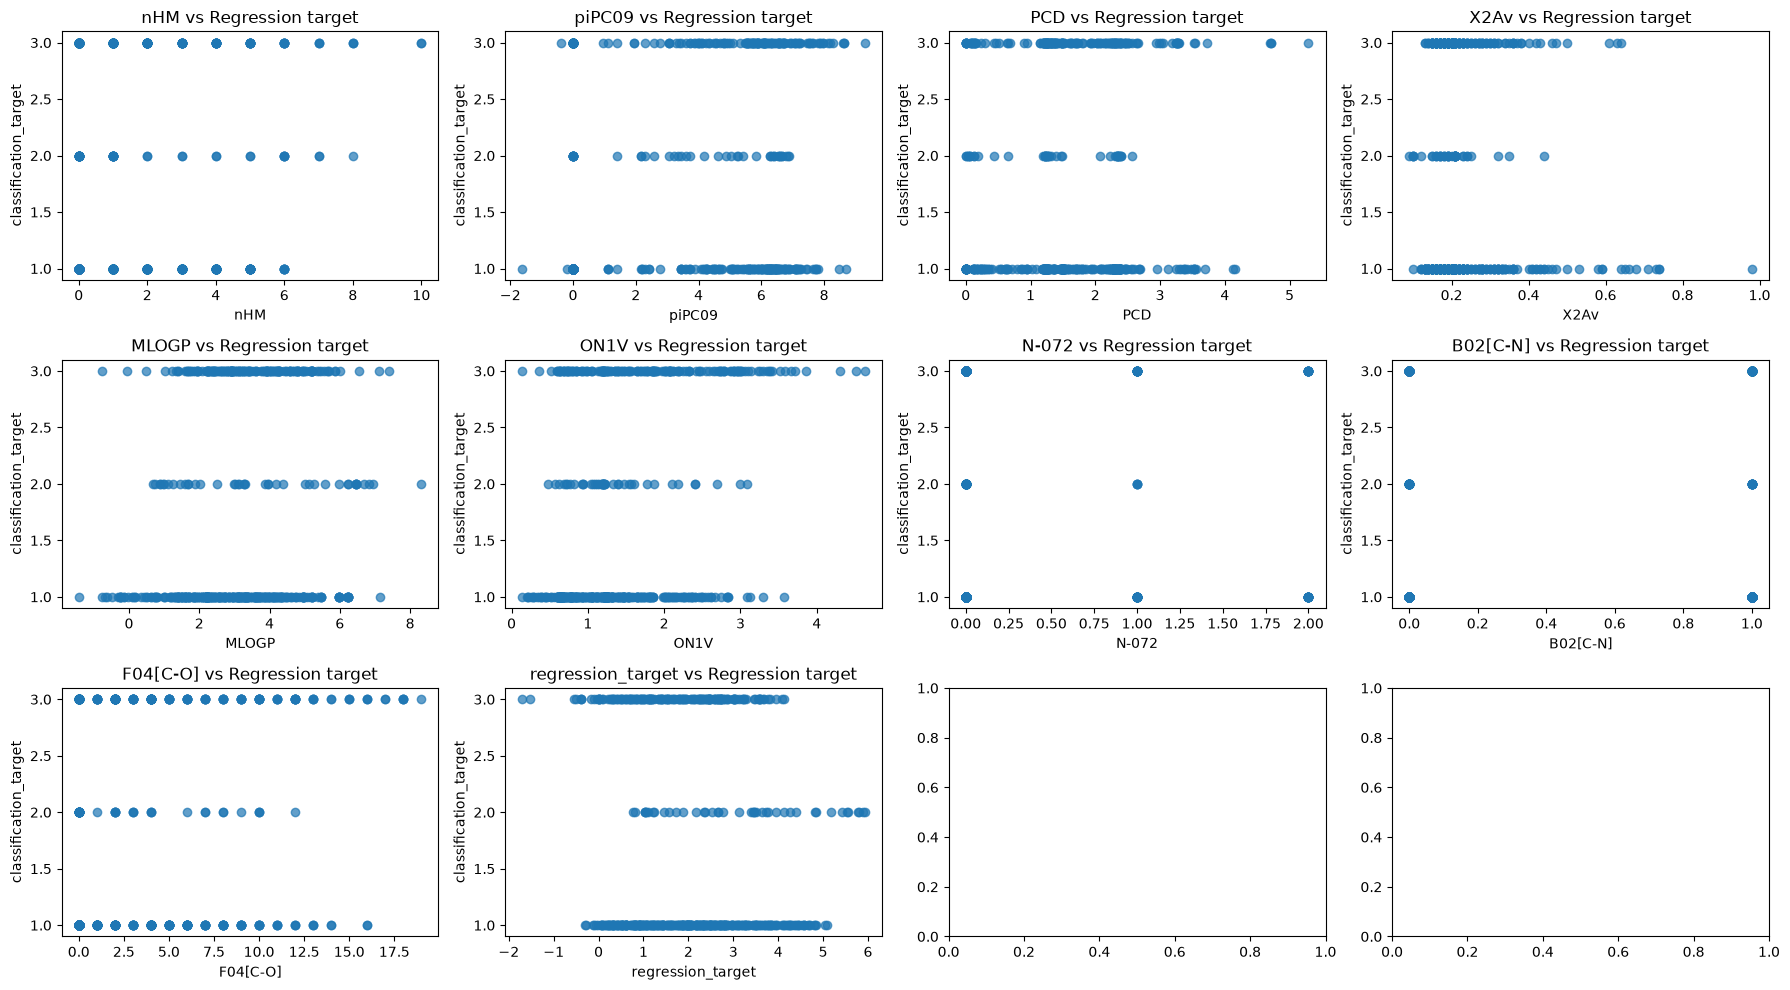

In [102]:
visualize_relationship(
    imputation_train,
    target_column="classification_target",
    exclude=["classification_target"],
    n_cols=4,
)

In [103]:
imputation_train.corr(method="pearson")

,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O],regression_target,classification_target
nHM,1.000000,0.098498,-0.031470,0.302233,0.393896,-0.241949,-0.074519,-0.244305,-0.103590,0.433525,0.056831
piPC09,0.098498,1.000000,0.736063,-0.304597,0.517768,0.516040,0.146304,0.029022,0.273714,0.455231,0.220023
PCD,-0.031470,0.736063,1.000000,-0.509335,0.486081,0.179191,-0.036570,0.101716,0.100394,0.400372,0.101753
X2Av,0.302233,-0.304597,-0.509335,1.000000,-0.205668,-0.039739,-0.044362,-0.246304,-0.096327,-0.088463,-0.042809
MLOGP,0.393896,0.517768,0.486081,-0.205668,1.000000,0.209427,-0.215881,-0.326786,-0.106986,0.788895,0.177215
ON1V,-0.241949,0.516040,0.179191,-0.039739,0.209427,1.000000,0.254905,0.158025,0.568306,0.144366,0.340105
N-072,-0.074519,0.146304,-0.036570,-0.044362,-0.215881,0.254905,1.000000,0.395522,0.207045,-0.196366,0.028710
B02[C-N],-0.244305,0.029022,0.101716,-0.246304,-0.326786,0.158025,0.395522,1.000000,0.203133,-0.319621,-0.101941
F04[C-O],-0.103590,0.273714,0.100394,-0.096327,-0.106986,0.568306,0.207045,0.203133,1.000000,-0.106938,0.279646
regression_target,0.433525,0.455231,0.400372,-0.088463,0.788895,0.144366,-0.196366,-0.319621,-0.106938,1.000000,-0.090602


In [104]:
imputation_train.corr(method="spearman")

,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O],regression_target,classification_target
nHM,1.000000,0.065035,0.005561,0.462438,0.305826,-0.253429,-0.050989,-0.190006,-0.026789,0.345714,0.019124
piPC09,0.065035,1.000000,0.794219,-0.322281,0.542786,0.579858,0.106337,-0.000465,0.219771,0.475023,0.208506
PCD,0.005561,0.794219,1.000000,-0.543342,0.500540,0.262123,-0.011978,0.119750,0.162196,0.414846,0.099821
X2Av,0.462438,-0.322281,-0.543342,1.000000,-0.052299,-0.056724,-0.047422,-0.296665,-0.186921,0.029359,0.001673
MLOGP,0.305826,0.542786,0.500540,-0.052299,1.000000,0.252164,-0.216884,-0.336463,-0.138800,0.802787,0.181600
ON1V,-0.253429,0.579858,0.262123,-0.056724,0.252164,1.000000,0.294579,0.150944,0.464241,0.211499,0.296187
N-072,-0.050989,0.106337,-0.011978,-0.047422,-0.216884,0.294579,1.000000,0.417603,0.297502,-0.194541,0.018790
B02[C-N],-0.190006,-0.000465,0.119750,-0.296665,-0.336463,0.150944,0.417603,1.000000,0.236640,-0.308070,-0.107209
F04[C-O],-0.026789,0.219771,0.162196,-0.186921,-0.138800,0.464241,0.297502,0.236640,1.000000,-0.108426,0.269951
regression_target,0.345714,0.475023,0.414846,0.029359,0.802787,0.211499,-0.194541,-0.308070,-0.108426,1.000000,-0.059936


In [105]:
X = imputation_train.drop(columns=["regression_target", "classification_target"])
y_reg = imputation_train["regression_target"].astype(float)
y_cls = imputation_train["classification_target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.20, random_state=RANDOM_STATE, stratify=y_cls
)


def regression_metrics(name, y_true, y_pred):
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


regression_results = []


def plot_observed_vs_predicted(y_true, y_pred, title):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    low = min(y_true.min(), y_pred.min())
    high = max(y_true.max(), y_pred.max())
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_true, y_pred, alpha=0.55, color="#4c78a8")
    ax.plot(
        [low, high],
        [low, high],
        color="#d62728",
        linestyle="--",
        linewidth=2,
        label="Perfect prediction",
    )
    ax.set_xlabel("Observed regression_target")
    ax.set_ylabel("Predicted regression_target")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend(frameon=True)
    fig.tight_layout()
    plt.show()

## Trying regression from models zoo

,model,MAE,RMSE,R2
0,Linear regression,0.623443,0.857492,0.548266


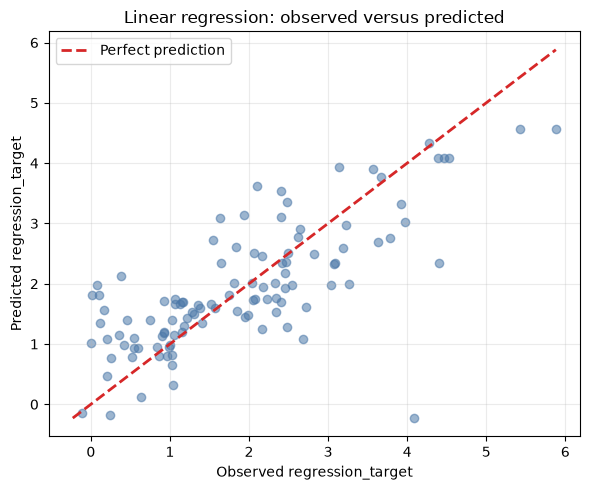

In [106]:
linear_model = Pipeline([("model", LinearRegression())])

linear_model.fit(X_train, y_train)
pred_linear = linear_model.predict(X_test)

regression_results.append(regression_metrics("Linear regression", y_test, pred_linear))

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(
    y_test, pred_linear, "Linear regression: observed versus predicted"
)

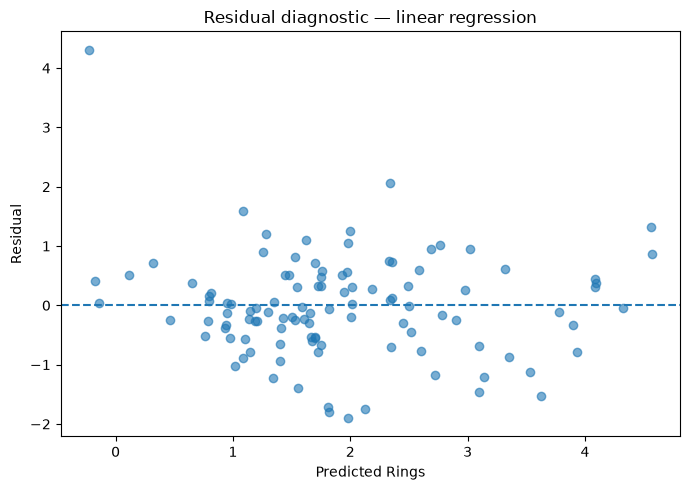

In [107]:
residuals = y_test.to_numpy() - pred_linear

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pred_linear, residuals, alpha=0.6)
ax.axhline(0, linestyle="--")
ax.set_xlabel("Predicted Rings")
ax.set_ylabel("Residual")
ax.set_title("Residual diagnostic — linear regression")
plt.tight_layout()
plt.show()

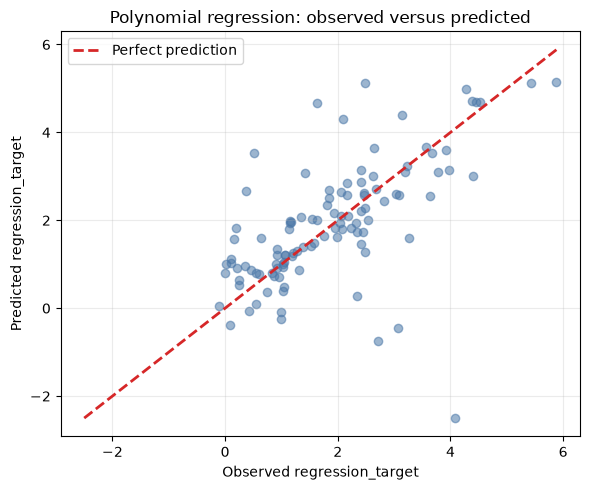

[{'model': 'Linear regression',
  'MAE': 0.6234426711827077,
  'RMSE': np.float64(0.8574924547152921),
  'R2': 0.5482660023589323},
 {'model': 'Polynomial (degree 3)',
  'MAE': 0.715897107259301,
  'RMSE': np.float64(1.1653314473623462),
  'R2': 0.16570220618316012}]

In [108]:
poly_model = Pipeline(
    [
        (
            "poly",
            PolynomialFeatures(degree=3, include_bias=False, interaction_only=False),
        ),
        ("model", Ridge(alpha=1.0)),
    ]
)

poly_model.fit(X_train, y_train)
pred_poly = poly_model.predict(X_test)

regression_results.append(
    regression_metrics("Polynomial (degree 3)", y_test, pred_poly)
)
plot_observed_vs_predicted(
    y_test, pred_poly, "Polynomial regression: observed versus predicted"
)
regression_results

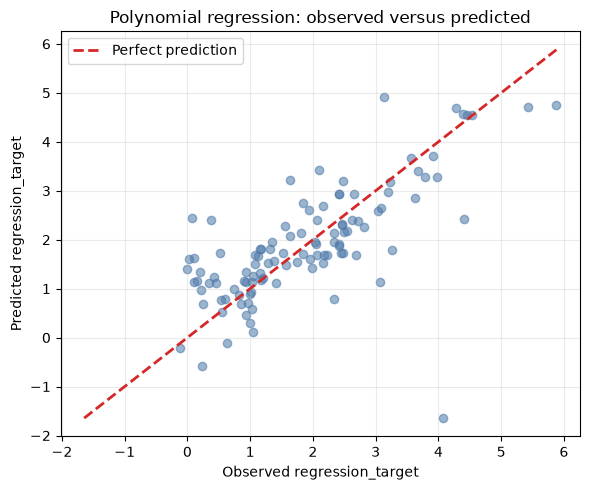

[{'model': 'Linear regression',
  'MAE': 0.6234426711827077,
  'RMSE': np.float64(0.8574924547152921),
  'R2': 0.5482660023589323},
 {'model': 'Polynomial (degree 3)',
  'MAE': 0.715897107259301,
  'RMSE': np.float64(1.1653314473623462),
  'R2': 0.16570220618316012},
 {'model': 'Polynomial (degree 2)',
  'MAE': 0.622819245387332,
  'RMSE': np.float64(0.9336906761474655),
  'R2': 0.4644152454454967}]

In [109]:
poly_model = Pipeline(
    [
        (
            "poly",
            PolynomialFeatures(degree=2, include_bias=False, interaction_only=False),
        ),
        ("model", Ridge(alpha=1.0)),
    ]
)

poly_model.fit(X_train, y_train)
pred_poly = poly_model.predict(X_test)

regression_results.append(
    regression_metrics("Polynomial (degree 2)", y_test, pred_poly)
)
plot_observed_vs_predicted(
    y_test, pred_poly, "Polynomial regression: observed versus predicted"
)
regression_results

,model,MAE,RMSE,R2
0,Linear regression,0.623443,0.857492,0.548266
1,Polynomial (degree 3),0.715897,1.165331,0.165702
2,Polynomial (degree 2),0.622819,0.933691,0.464415
3,Spline + Ridge,0.596716,0.815833,0.591093


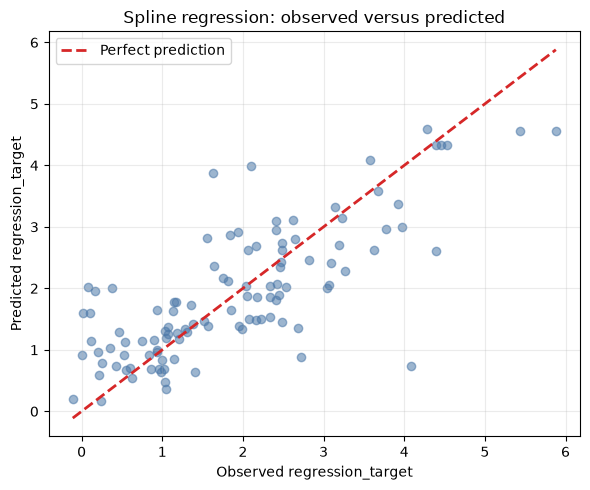

In [110]:
num_cols = X.select_dtypes(include=np.number).columns.tolist()
spline_preprocessor = ColumnTransformer(
    [
        (
            "num_spline",
            Pipeline(
                [
                    ("scale", StandardScaler()),
                    (
                        "spline",
                        SplineTransformer(n_knots=5, degree=3, include_bias=False),
                    ),
                ]
            ),
            num_cols,
        )
    ]
)

spline_model = Pipeline([("prep", spline_preprocessor), ("model", Ridge(alpha=1.0))])

spline_model.fit(X_train, y_train)
pred_spline = spline_model.predict(X_test)

regression_results.append(regression_metrics("Spline + Ridge", y_test, pred_spline))

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(
    y_test, pred_spline, "Spline regression: observed versus predicted"
)

,model,MAE,RMSE,R2
0,Linear regression,0.623443,0.857492,0.548266
1,Polynomial (degree 3),0.715897,1.165331,0.165702
2,Polynomial (degree 2),0.622819,0.933691,0.464415
3,Spline + Ridge,0.596716,0.815833,0.591093
4,Huber regression,0.625502,0.864029,0.541352


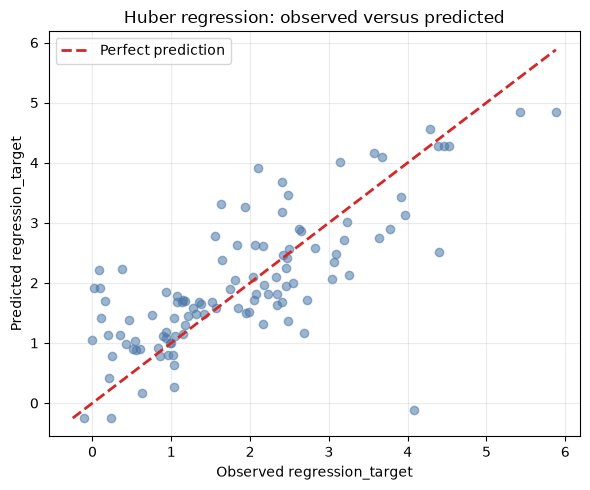

In [111]:
huber_model = Pipeline([("model", HuberRegressor(max_iter=3000))])

huber_model.fit(X_train, y_train)
pred_huber = huber_model.predict(X_test)

regression_results.append(regression_metrics("Huber regression", y_test, pred_huber))

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(
    y_test, pred_huber, "Huber regression: observed versus predicted"
)

In [112]:
quantile_model = Pipeline(
    [("model", QuantileRegressor(quantile=0.25, alpha=0.01, solver="highs"))]
)

quantile_model.fit(X_train, y_train)
pred_quantile = quantile_model.predict(X_test)

regression_results.append(
    regression_metrics("Quantile regression (25)", y_test, pred_quantile)
)

display(pd.DataFrame(regression_results))

,model,MAE,RMSE,R2
0,Linear regression,0.623443,0.857492,0.548266
1,Polynomial (degree 3),0.715897,1.165331,0.165702
2,Polynomial (degree 2),0.622819,0.933691,0.464415
3,Spline + Ridge,0.596716,0.815833,0.591093
4,Huber regression,0.625502,0.864029,0.541352
5,Quantile regression (25),0.708099,0.964062,0.429006


,model,MAE,RMSE,R2
0,Linear regression,0.623443,0.857492,0.548266
1,Polynomial (degree 3),0.715897,1.165331,0.165702
2,Polynomial (degree 2),0.622819,0.933691,0.464415
3,Spline + Ridge,0.596716,0.815833,0.591093
4,Huber regression,0.625502,0.864029,0.541352
5,Quantile regression (25),0.708099,0.964062,0.429006
6,PCR (5 PCs),0.677964,0.876946,0.527537


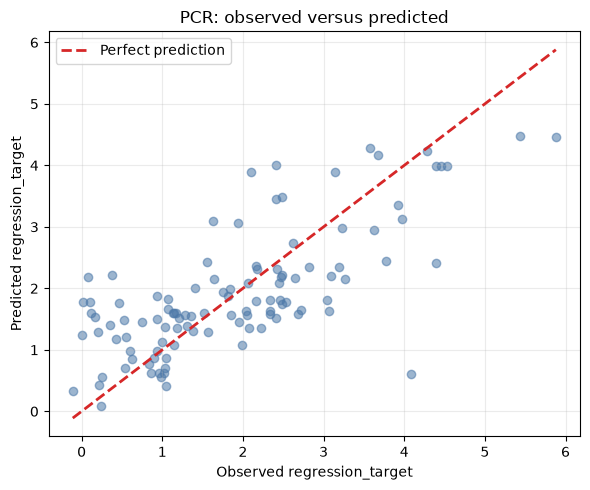

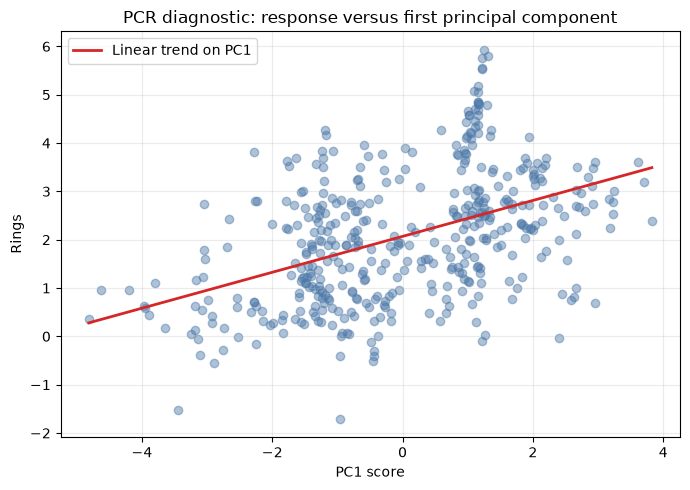

In [113]:
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), num_cols)])
pcr_model = Pipeline(
    [
        ("prep", preprocessor),
        ("pca", PCA(n_components=5)),
        ("model", LinearRegression()),
    ]
)

pcr_model.fit(X_train, y_train)
pred_pcr = pcr_model.predict(X_test)

regression_results.append(regression_metrics("PCR (5 PCs)", y_test, pred_pcr))

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(y_test, pred_pcr, "PCR: observed versus predicted")

# Visualize the first principal component as a one-dimensional diagnostic.
X_train_pca = pcr_model.named_steps["pca"].transform(
    pcr_model.named_steps["prep"].transform(X_train)
)
pc1 = X_train_pca[:, 0]
pc1_line = np.polyfit(pc1, y_train.to_numpy(), deg=1)
pc1_grid = np.linspace(pc1.min(), pc1.max(), 100)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pc1, y_train, alpha=0.45, color="#4c78a8")
ax.plot(
    pc1_grid,
    np.polyval(pc1_line, pc1_grid),
    color="#d62728",
    linewidth=2,
    label="Linear trend on PC1",
)
ax.set_xlabel("PC1 score")
ax.set_ylabel("Rings")
ax.set_title("PCR diagnostic: response versus first principal component")
ax.grid(alpha=0.25)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

,model,MAE,RMSE,R2
0,Linear regression,0.623443,0.857492,0.548266
1,Polynomial (degree 3),0.715897,1.165331,0.165702
2,Polynomial (degree 2),0.622819,0.933691,0.464415
3,Spline + Ridge,0.596716,0.815833,0.591093
4,Huber regression,0.625502,0.864029,0.541352
5,Quantile regression (25),0.708099,0.964062,0.429006
6,PCR (5 PCs),0.677964,0.876946,0.527537
7,PLSR (5 components),0.617546,0.849870,0.556261


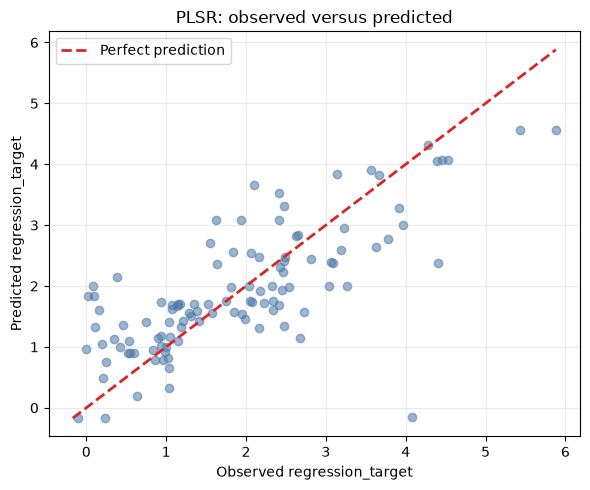

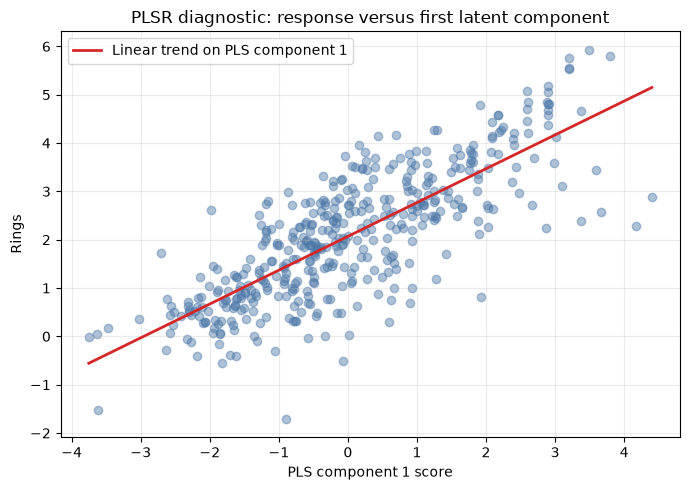

In [114]:
pls = PLSRegression(n_components=5)
pls.fit(X_train, y_train)

pred_pls = pls.predict(X_test).ravel()

regression_results.append(regression_metrics("PLSR (5 components)", y_test, pred_pls))

display(pd.DataFrame(regression_results))
plot_observed_vs_predicted(y_test, pred_pls, "PLSR: observed versus predicted")

pls1 = pls.x_scores_[:, 0]
pls1_line = np.polyfit(pls1, y_train.to_numpy(), deg=1)
pls1_grid = np.linspace(pls1.min(), pls1.max(), 100)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pls1, y_train, alpha=0.45, color="#4c78a8")
ax.plot(
    pls1_grid,
    np.polyval(pls1_line, pls1_grid),
    color="#d62728",
    linewidth=2,
    label="Linear trend on PLS component 1",
)
ax.set_xlabel("PLS component 1 score")
ax.set_ylabel("Rings")
ax.set_title("PLSR diagnostic: response versus first latent component")
ax.grid(alpha=0.25)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

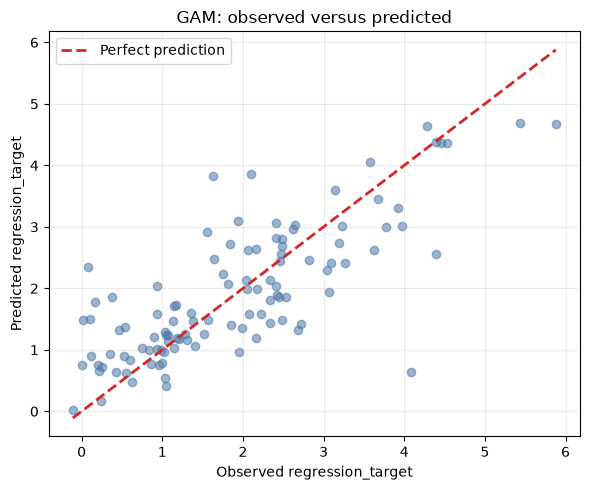

,model,MAE,RMSE,R2
0,Linear regression,0.623443,0.857492,0.548266
1,Polynomial (degree 3),0.715897,1.165331,0.165702
2,Polynomial (degree 2),0.622819,0.933691,0.464415
3,Spline + Ridge,0.596716,0.815833,0.591093
4,Huber regression,0.625502,0.864029,0.541352
5,Quantile regression (25),0.708099,0.964062,0.429006
6,PCR (5 PCs),0.677964,0.876946,0.527537
7,PLSR (5 components),0.617546,0.849870,0.556261
8,GAM,0.585014,0.804606,0.602269


In [115]:
try:
    from pygam import LinearGAM, s

    X_gam_train = X_train.to_numpy()
    X_gam_test = X_test.to_numpy()

    # One smooth term per numeric predictor
    gam = LinearGAM(
        s(0, n_splines=10)
        + s(1, n_splines=10)
        + s(2, n_splines=10)
        + s(3, n_splines=10)
        + s(4, n_splines=10)
        + s(5, n_splines=10)
        + s(6, n_splines=10)
    ).fit(X_gam_train, y_train)

    pred_gam = gam.predict(X_gam_test)

    regression_results.append(regression_metrics("GAM", y_test, pred_gam))
    plot_observed_vs_predicted(y_test, pred_gam, "GAM: observed versus predicted")

except Exception as e:
    print("GAM was not run:", e)
    print("Install pygam to execute this section.")

display(pd.DataFrame(regression_results))

/Users/otsep/Desktop/Personal/KSE/ml/personal/KSE_ML_for_bioinformatics/.venv/lib/python3.11/site-packages/pysr/sr.py:2405: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


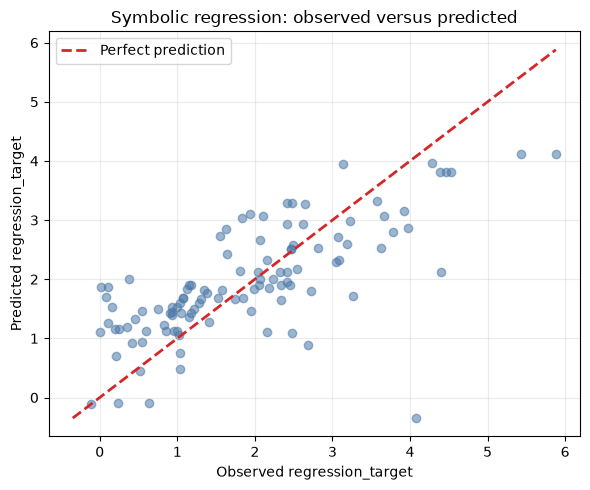

Selected symbolic equation:


MLOGP + 2.0686288

In [116]:
X_sym_train = X_train.to_numpy()
X_sym_test = X_test.to_numpy()
sym_features = X_train.columns.str.replace(r"[^a-zA-Z0-9_]", "_", regex=True).tolist()

sym_scaler = StandardScaler()
X_sym_train_s = sym_scaler.fit_transform(X_sym_train)
X_sym_test_s = sym_scaler.transform(X_sym_test)

try:
    from pysr import PySRRegressor

    symbolic_model = PySRRegressor(
        niterations=10,
        populations=10,
        population_size=20,
        binary_operators=["+", "-", "*", "/"],
        unary_operators=["square", "cube", "cos", "exp", "sin", "sqrt"],
        maxsize=10,
        random_state=RANDOM_STATE,
        verbosity=0,
    )

    symbolic_model.fit(X_sym_train_s, y_train, variable_names=sym_features)

    pred_symbolic = symbolic_model.predict(X_sym_test_s)

    regression_results.append(
        regression_metrics("Symbolic regression", y_test, pred_symbolic)
    )
    plot_observed_vs_predicted(
        y_test, pred_symbolic, "Symbolic regression: observed versus predicted"
    )

    print("Selected symbolic equation:")
    display(symbolic_model.sympy())

except Exception as e:
    print("Symbolic regression was not run:", e)
    print("Install/configure PySR, then rerun this cell.")

In [117]:
regression_table = (
    pd.DataFrame(regression_results).sort_values("RMSE").reset_index(drop=True)
)

display(regression_table)

,model,MAE,RMSE,R2
0,GAM,0.585014,0.804606,0.602269
1,Spline + Ridge,0.596716,0.815833,0.591093
2,PLSR (5 components),0.617546,0.849870,0.556261
3,Linear regression,0.623443,0.857492,0.548266
4,Huber regression,0.625502,0.864029,0.541352
5,PCR (5 PCs),0.677964,0.876946,0.527537
6,Symbolic regression,0.673652,0.895191,0.507673
7,Polynomial (degree 2),0.622819,0.933691,0.464415
8,Quantile regression (25),0.708099,0.964062,0.429006
9,Polynomial (degree 3),0.715897,1.165331,0.165702


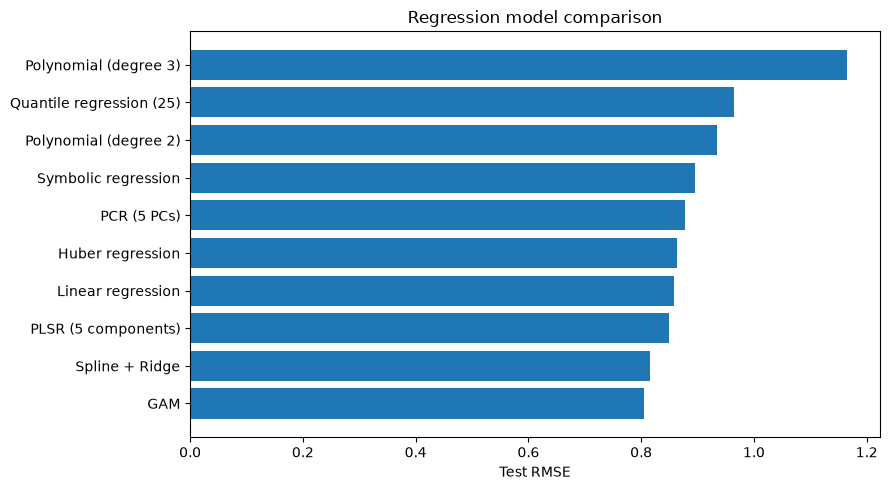

In [118]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = regression_table.sort_values("RMSE", ascending=True)
ax.barh(plot_df["model"], plot_df["RMSE"])
ax.set_xlabel("Test RMSE")
ax.set_title("Regression model comparison")
plt.tight_layout()
plt.show()

## Classificaion

In [ ]:
X_cls = imputation_train.drop(columns=["classification_target", "regression_target"])
y_cls = imputation_train["classification_target"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.20, random_state=RANDOM_STATE, stratify=y_cls
)

classification_model = Pipeline(
    [
        (
            "interactions",
            PolynomialFeatures(degree=2, interaction_only=True, include_bias=True),
        ),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced")),
    ]
)

classification_model.fit(Xc_train, yc_train)

cls_pred = classification_model.predict(Xc_test)
cls_proba = classification_model.predict_proba(Xc_test)

print(classification_report(yc_test, cls_pred))
print("Balanced accuracy:", balanced_accuracy_score(yc_test, cls_pred))
print("Macro F1:", f1_score(yc_test, cls_pred, average="macro"))

              precision    recall  f1-score   support

           1       0.67      0.52      0.58        64
           2       0.17      0.44      0.24         9
           3       0.53      0.53      0.53        36

    accuracy                           0.51       109
   macro avg       0.46      0.50      0.45       109
weighted avg       0.58      0.51      0.54       109

Balanced accuracy: 0.4959490740740741
Macro F1: 0.45142427222073245


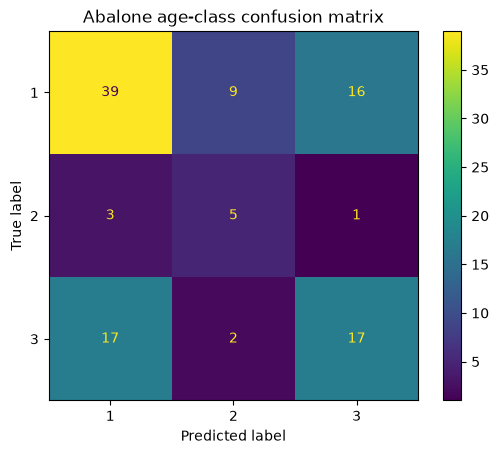

In [120]:
ConfusionMatrixDisplay.from_predictions(yc_test, cls_pred, cmap=None)

plt.title("Abalone age-class confusion matrix")
plt.show()

In [ ]:
X_cls_with_rt = imputation_train.drop(columns=["classification_target"])
y_cls = imputation_train["classification_target"]

Xc_train_with_rt, Xc_test_with_rt, yc_train, yc_test = train_test_split(
    X_cls_with_rt, y_cls, test_size=0.20, random_state=RANDOM_STATE, stratify=y_cls
)

classification_model_with_rt = Pipeline(
    [
        (
            "interactions",
            PolynomialFeatures(degree=2, interaction_only=True, include_bias=True),
        ),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced")),
    ]
)

classification_model_with_rt.fit(Xc_train_with_rt, yc_train)

cls_pred = classification_model_with_rt.predict(Xc_test_with_rt)
cls_proba = classification_model_with_rt.predict_proba(Xc_test_with_rt)

print(classification_report(yc_test, cls_pred))
print("Balanced accuracy:", balanced_accuracy_score(yc_test, cls_pred))
print("Macro F1:", f1_score(yc_test, cls_pred, average="macro"))

              precision    recall  f1-score   support

           1       0.79      0.69      0.73        64
           2       0.46      0.67      0.55         9
           3       0.68      0.75      0.71        36

    accuracy                           0.71       109
   macro avg       0.64      0.70      0.66       109
weighted avg       0.72      0.71      0.71       109

Balanced accuracy: 0.7013888888888888
Macro F1: 0.6631047315257842


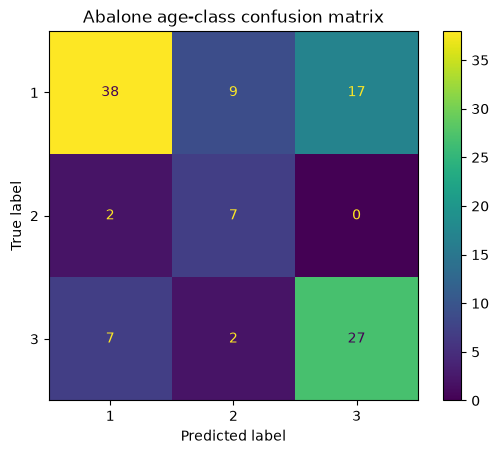

In [122]:
ConfusionMatrixDisplay.from_predictions(yc_test, cls_pred, cmap=None)

plt.title("Abalone age-class confusion matrix")
plt.show()

In [144]:
Xc_test_pred_rt = Xc_test.copy()
Xc_test_pred_rt["regression_target"] = gam.predict(Xc_test_pred_rt).ravel()


cls_pred = classification_model_with_rt.predict(Xc_test_pred_rt)
cls_proba = classification_model_with_rt.predict_proba(Xc_test_pred_rt)

print(classification_report(yc_test, cls_pred))
print("Balanced accuracy:", balanced_accuracy_score(yc_test, cls_pred))
print("Macro F1:", f1_score(yc_test, cls_pred, average="macro"))

              precision    recall  f1-score   support

           1       0.68      0.66      0.67        64
           2       0.23      0.33      0.27         9
           3       0.47      0.44      0.46        36

    accuracy                           0.56       109
   macro avg       0.46      0.48      0.47       109
weighted avg       0.57      0.56      0.56       109

Balanced accuracy: 0.47800925925925924
Macro F1: 0.4655122655122655


In [ ]:
Xc_train_pred_rt = Xc_train.copy()
Xc_test_pred_rt = Xc_test.copy()
Xc_train_pred_rt["pls_predicted_regression"] = gam.predict(Xc_train_pred_rt).ravel()
Xc_test_pred_rt["pls_predicted_regression"] = gam.predict(Xc_test_pred_rt).ravel()

classification_model_pred_rt = Pipeline(
    [
        (
            "interactions",
            PolynomialFeatures(degree=2, interaction_only=True, include_bias=True),
        ),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced")),
    ]
)

classification_model_pred_rt.fit(Xc_train_pred_rt, yc_train)

cls_pred = classification_model_pred_rt.predict(Xc_test_pred_rt)
cls_proba = classification_model_pred_rt.predict_proba(Xc_test_pred_rt)

print(classification_report(yc_test, cls_pred))
print("Balanced accuracy:", balanced_accuracy_score(yc_test, cls_pred))
print("Macro F1:", f1_score(yc_test, cls_pred, average="macro"))

              precision    recall  f1-score   support

           1       0.69      0.58      0.63        64
           2       0.30      0.67      0.41         9
           3       0.43      0.42      0.42        36

    accuracy                           0.53       109
   macro avg       0.47      0.55      0.49       109
weighted avg       0.57      0.53      0.54       109

Balanced accuracy: 0.5538194444444444
Macro F1: 0.4878156529278927


In [147]:
# checking weights adjustment on simple classifier + regression prediction, on train
probas = classification_model_pred_rt.predict_proba(Xc_train_pred_rt)

best_balanced_acc = 0
best_threshold_multipliers_pred_rt = (1.0, 1.0, 1.0)

for w1 in [1.0]:
    for w2 in np.linspace(0.4, 1.5, 12):
        for w3 in np.linspace(0.8, 1.4, 7):
            multipliers = np.array([w1, w2, w3])
            adjusted_probas = probas * multipliers
            preds_idx = np.argmax(adjusted_probas, axis=1)
            preds = classification_model_pred_rt.classes_[preds_idx]
            score = balanced_accuracy_score(yc_train, preds)

            if score > best_balanced_acc:
                best_balanced_acc = score
                best_threshold_multipliers_pred_rt = multipliers

print(f"Best Balanced Accuracy: {best_balanced_acc:.4f}")
print(f"Optimal Class Multipliers : {best_threshold_multipliers_pred_rt}")


Best Balanced Accuracy: 0.7418
Optimal Class Multipliers : [1.  1.  1.4]


In [148]:
# checking weights adjustment on simple classifier + regression prediction, on test
def predict_with_thresholds(model, X_data, multipliers):
    raw_probs = model.predict_proba(X_data)
    scaled_probs = raw_probs * multipliers
    final_pred_indices = np.argmax(scaled_probs, axis=1)
    return model.classes_[final_pred_indices]


cls_pred = predict_with_thresholds(
    classification_model_pred_rt, Xc_test_pred_rt, best_threshold_multipliers_pred_rt
)

print(classification_report(yc_test, cls_pred, zero_division=0))
print(f"Optimized Balanced Accuracy: {balanced_accuracy_score(yc_test, cls_pred):.4f}")


              precision    recall  f1-score   support

           1       0.70      0.52      0.59        64
           2       0.30      0.67      0.41         9
           3       0.43      0.50      0.46        36

    accuracy                           0.52       109
   macro avg       0.48      0.56      0.49       109
weighted avg       0.58      0.52      0.54       109

Optimized Balanced Accuracy: 0.5608


In [155]:
train.columns

Index(['sample_id', 'nHM', 'piPC09', 'PCD', 'X2Av', 'MLOGP', 'ON1V', 'N-072',
       'B02[C-N]', 'F04[C-O]', 'regression_target', 'classification_target'],
      dtype='str')

In [149]:
# checking weights adjustment on simple classifier, on train
probas = classification_model.predict_proba(Xc_train)

best_balanced_acc = 0
best_threshold_multipliers = (1.0, 1.0, 1.0)

for w1 in [1.0]:
    for w2 in np.linspace(0.4, 1.5, 12):
        for w3 in np.linspace(0.8, 1.4, 7):
            multipliers = np.array([w1, w2, w3])
            adjusted_probas = probas * multipliers
            preds_idx = np.argmax(adjusted_probas, axis=1)
            preds = classification_model.classes_[preds_idx]
            score = balanced_accuracy_score(yc_train, preds)

            if score > best_balanced_acc:
                best_balanced_acc = score
                best_threshold_multipliers = multipliers

print(f"Best Balanced Accuracy: {best_balanced_acc:.4f}")
print(f"Optimal Class Multipliers : {best_threshold_multipliers}")

Best Balanced Accuracy: 0.5704
Optimal Class Multipliers : [1.  0.9 0.9]


In [150]:
# checking weights adjustment on simple classifier, on test
def predict_with_thresholds(model, X_data, multipliers):
    raw_probs = model.predict_proba(X_data)
    scaled_probs = raw_probs * multipliers
    final_pred_indices = np.argmax(scaled_probs, axis=1)
    return model.classes_[final_pred_indices]


cls_pred = predict_with_thresholds(
    classification_model, Xc_test, best_threshold_multipliers
)

print(classification_report(yc_test, cls_pred, zero_division=0))
print(f"Optimized Balanced Accuracy: {balanced_accuracy_score(yc_test, cls_pred):.4f}")

              precision    recall  f1-score   support

           1       0.64      0.53      0.58        64
           2       0.14      0.33      0.20         9
           3       0.51      0.50      0.51        36

    accuracy                           0.50       109
   macro avg       0.43      0.45      0.43       109
weighted avg       0.56      0.50      0.53       109

Optimized Balanced Accuracy: 0.4549


## Predict true test

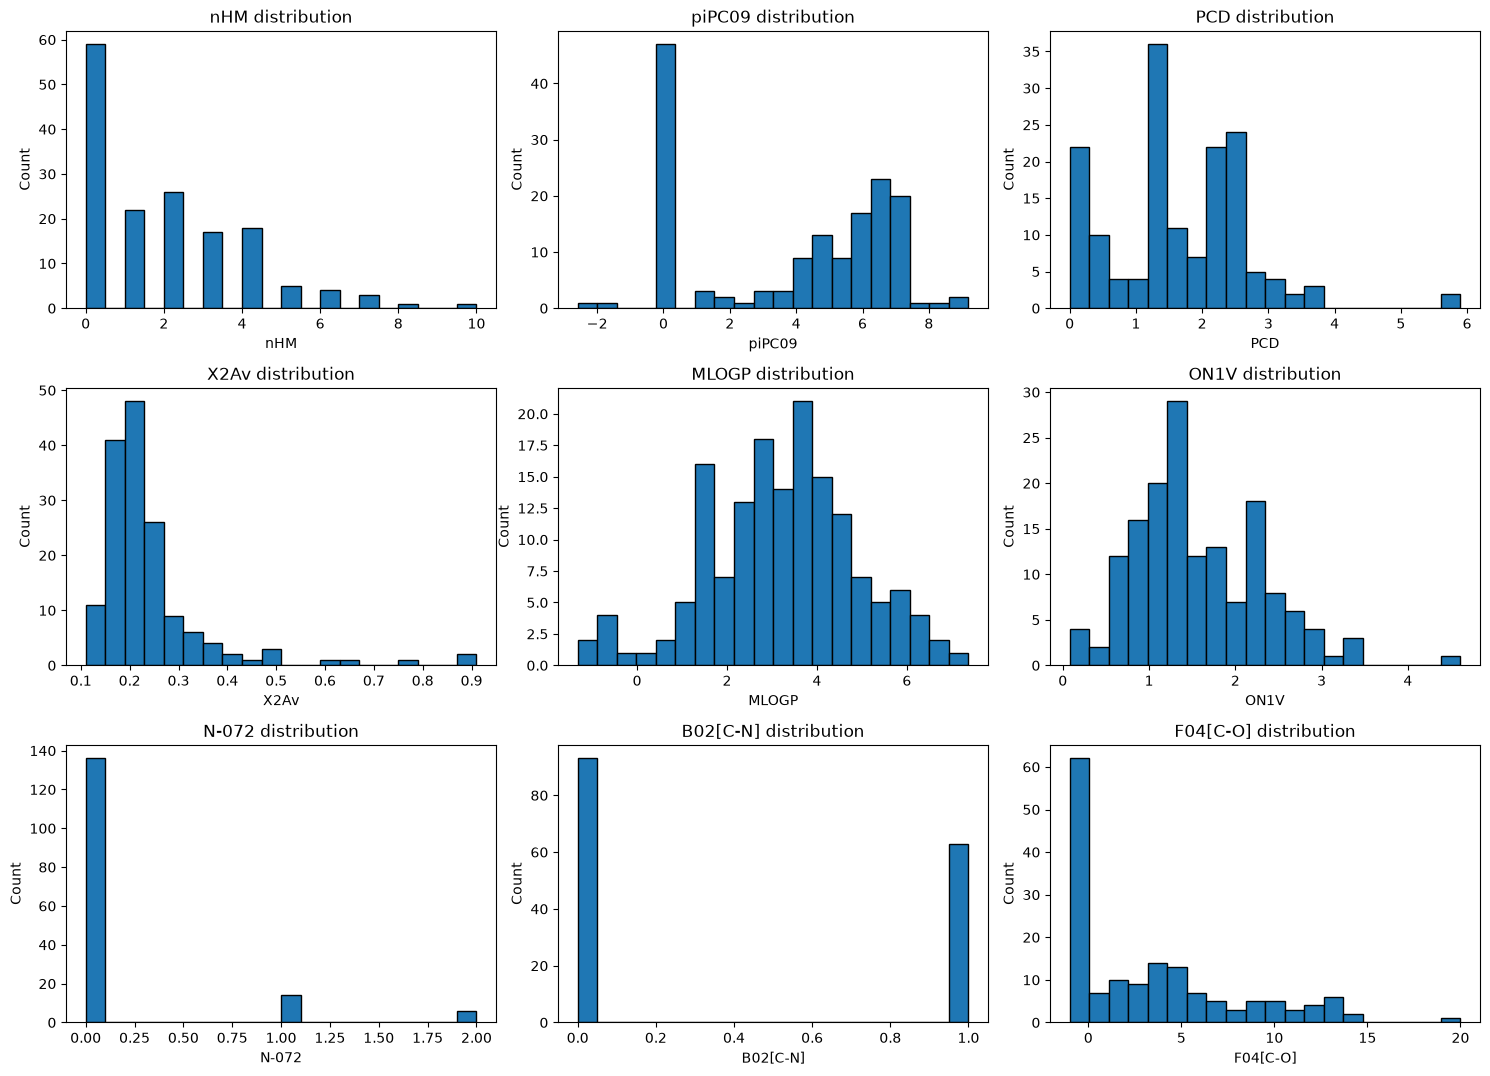

In [151]:
imputation_test = test.drop(columns="sample_id")
test_imputed = mice_im.transform(imputation_test)
imputation_test = pd.DataFrame(test_imputed, columns=imputation_test.columns)
imputation_test["nHM"] = imputation_test["nHM"].round()
imputation_test["N-072"] = imputation_test["N-072"].round()
imputation_test["B02[C-N]"] = imputation_test["B02[C-N]"].round()
imputation_test["F04[C-O]"] = imputation_test["F04[C-O]"].round()
visualize_col_distr(imputation_test)


In [152]:
imputation_test["pls_predicted_regression"] = gam.predict(imputation_test).ravel()
cls_pred = predict_with_thresholds(
    classification_model_pred_rt, imputation_test, best_threshold_multipliers_pred_rt
)
imputation_test["classification_target"] = cls_pred

submission_df = pd.DataFrame(
    {
        "sample_id": test["sample_id"],
        "regression_prediction": imputation_test["pls_predicted_regression"],
        "classification_prediction": imputation_test["classification_target"],
    }
)
display(submission_df.head())

,sample_id,regression_prediction,classification_prediction
0,78-79-5,1.139954,1
1,16606-02-3,3.808971,1
2,111-44-4,0.667363,1
3,107-05-1,0.635512,1
4,555-03-3,0.758192,1


In [153]:
submission_df.to_csv("simple_sub_prefilt.csv")